# Naive Bayes

## Overview
Naive Bayes Classification – NBA Player Longevity Prediction
Project Overview
In this project, you will analyze engineered NBA player data using Python and Scikit-learn to build a Gaussian Naive Bayes classification model. You will learn how to identify target variables, implement probabilistic classifiers, evaluate performance using confusion matrices and business-relevant metrics, and interpret model assumptions in the context of sports analytics. This project helps you translate statistical predictions into actionable scouting insights.

## Importing Libraries

In [54]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

Load the dataset and clearly define the `target_5yrs` column as the dependent variable

In [55]:
# Load the Housing dataset
data = pd.read_csv('extracted_nba_players_data.csv')

In [56]:
data.shape

(1340, 11)

In [57]:
print("First five rows of the dataset:")
data.head()

First five rows of the dataset:


,fg,3p,ft,reb,ast,stl,blk,tov,target_5yrs,total_points,efficiency
0,34.7,25.0,69.9,4.1,1.9,0.4,0.4,1.3,0,266.4,0.270073
1,29.6,23.5,76.5,2.4,3.7,1.1,0.5,1.6,0,252.0,0.267658
2,42.2,24.4,67.0,2.2,1.0,0.5,0.3,1.0,0,384.8,0.339869
3,42.6,22.6,68.9,1.9,0.8,0.6,0.1,1.0,1,330.6,0.491379
4,52.4,0.0,67.4,2.5,0.3,0.3,0.4,0.8,1,216.0,0.391304


In [58]:
# Display summary statistics
print("\nSummary statistics:")
print(data.describe())


Summary statistics:
                fg           3p           ft          reb          ast  \
count  1340.000000  1340.000000  1340.000000  1340.000000  1340.000000   
mean     44.169403    19.149627    70.300299     3.034478     1.550522   
std       6.137679    16.051861    10.578479     2.057774     1.471169   
min      23.800000     0.000000     0.000000     0.300000     0.000000   
25%      40.200000     0.000000    64.700000     1.500000     0.600000   
50%      44.100000    22.200000    71.250000     2.500000     1.100000   
75%      47.900000    32.500000    77.600000     4.000000     2.000000   
max      73.700000   100.000000   100.000000    13.900000    10.600000   

               stl          blk          tov  target_5yrs  total_points  \
count  1340.000000  1340.000000  1340.000000  1340.000000   1340.000000   
mean      0.618507     0.368582     1.193582     0.620149    451.783358   
std       0.409759     0.429049     0.722541     0.485531    366.520093   
min       0.

Add a visualization (e.g., sns.countplot) to check the distribution of 'target_5yrs'.

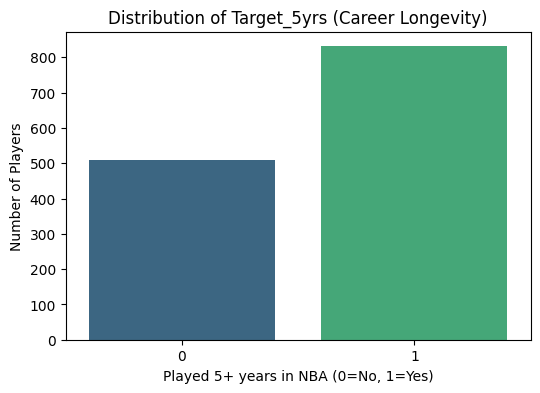

In [59]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target_5yrs', data=data, hue='target_5yrs', palette='viridis', legend=False)
plt.title('Distribution of Target_5yrs (Career Longevity)')
plt.xlabel('Played 5+ years in NBA (0=No, 1=Yes)')
plt.ylabel('Number of Players')
plt.show()

## Check for class balance/distribution of the target variable.

## Checking Class Balance of Target Variable
We will visualize the distribution of the `target_5yrs` column to understand the balance between the two classes (players who played 5+ years in NBA vs. those who did not). This is important for evaluating model performance, especially if the classes are imbalanced.

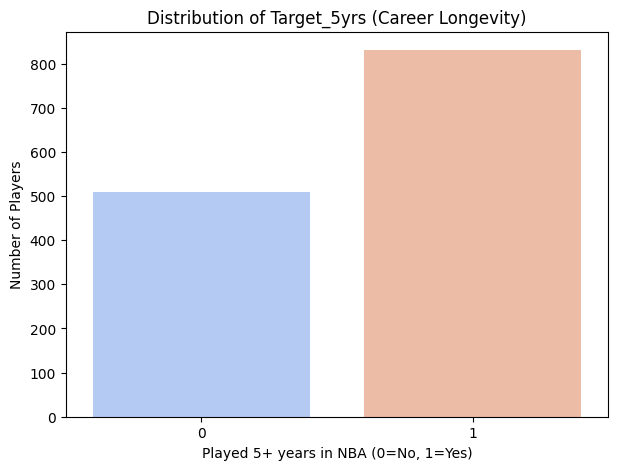


Value counts for 'target_5yrs':
target_5yrs
1    831
0    509
Name: count, dtype: int64


In [60]:
plt.figure(figsize=(7, 5))
sns.countplot(x='target_5yrs', data=data, hue='target_5yrs', palette='coolwarm', legend=False)
plt.title('Distribution of Target_5yrs (Career Longevity)')
plt.xlabel('Played 5+ years in NBA (0=No, 1=Yes)')
plt.ylabel('Number of Players')
plt.show()

# Also print the value counts for a numerical summary
print("\nValue counts for 'target_5yrs':")
print(data['target_5yrs'].value_counts())

Preprocess features to ensure compatibility with Gaussian Naive Bayes (continuous metrics)

In [68]:
X = data.drop(columns=["target_5yrs"])
y = data["target_5yrs"]

X.head(5)

,fg,3p,ft,reb,ast,stl,blk,tov,total_points,efficiency
0,34.7,25.0,69.9,4.1,1.9,0.4,0.4,1.3,266.4,0.270073
1,29.6,23.5,76.5,2.4,3.7,1.1,0.5,1.6,252.0,0.267658
2,42.2,24.4,67.0,2.2,1.0,0.5,0.3,1.0,384.8,0.339869
3,42.6,22.6,68.9,1.9,0.8,0.6,0.1,1.0,330.6,0.491379
4,52.4,0.0,67.4,2.5,0.3,0.3,0.4,0.8,216.0,0.391304


In [46]:
# Splitting into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Feature Scaling
Implementing feature scaling using `sklearn.preprocessing.StandardScaler`. Scaling is performed after splitting the data to ensure that the scaling parameters are learned only from the training data, preventing data leakage from the test set.

In [69]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames, preserving column names
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("X_train after scaling:")
display(X_train.head())
print("\nX_test after scaling:")
display(X_test.head())

X_train after scaling:


,gp,min,fg,3p_made,3p,ftm,ft,oreb,dreb,ast,stl,blk,tov,atr,rpm
1148,-0.123668,-0.573187,0.122067,-0.645468,-1.203611,-0.506060,-1.006863,0.136788,-0.148616,-0.855205,-1.013627,2.417345,-0.680326,0.113643,-0.067137
807,-1.266042,-1.094982,-0.538087,-0.645468,-1.203611,-0.813424,-0.573136,-0.516674,-0.672189,-0.855205,-1.013627,0.079808,-0.957367,0.077189,-0.036551
1287,0.390400,-0.099931,0.685612,-0.645468,-0.636935,-0.403606,-0.846573,-0.124597,-0.148616,-0.516284,0.931086,-0.153946,-0.541806,0.083163,0.010781
590,1.247180,1.271299,-0.216061,1.724194,0.975911,-0.096242,0.963765,0.398173,0.524550,-0.448500,0.201818,0.313561,0.012276,-3.673670,-0.046887
1188,-1.437398,-1.459026,-0.956721,-0.382172,0.577370,-1.120788,-1.252013,-1.039443,-1.195762,-0.787421,-1.013627,-0.153946,-0.957367,0.070094,-0.023737



X_test after scaling:


,gp,min,fg,3p_made,3p,ftm,ft,oreb,dreb,ast,stl,blk,tov,atr,rpm
394,-0.751974,-1.046443,-0.940620,-0.645468,-1.203611,-0.198697,-0.148838,-1.039443,-1.195762,-0.787421,-0.284360,-0.621453,-0.680326,0.103658,-0.006392
881,-1.208924,-0.973635,-1.343153,-0.645468,-0.786388,-1.018333,-1.921461,-1.039443,-1.046170,-0.855205,-1.256716,-0.621453,-0.957367,0.077189,-0.006217
358,1.075824,0.870851,1.120348,-0.645468,-1.203611,0.108667,0.756330,1.313019,1.347308,-0.719636,-0.284360,1.716084,0.427837,-0.180889,0.019994
367,-1.780111,-0.136335,-2.003306,1.197603,0.733050,-0.915879,-1.921461,-0.908751,-0.672189,-0.109580,-0.041271,-0.387700,-0.264765,0.029146,0.265261
259,-0.123668,-0.536783,-1.085532,-0.382172,0.290919,-0.915879,0.143456,-0.908751,-0.971374,1.042749,-0.770538,-0.621453,-0.264765,-0.407003,0.032851


### Features for Gaussian Naive Bayes

Gaussian Naive Bayes assumes that the features are continuous and follow a Gaussian (normal) distribution. Our features have already been scaled using `StandardScaler`, which transforms them to have a mean of 0 and a standard deviation of 1. This scaling step helps to meet the distributional assumptions of Gaussian Naive Bayes, making the data suitable for this classifier.

In [70]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


### Training the Gaussian Naive Bayes Model

In [71]:
# Initialize the Gaussian Naive Bayes model
gnb = GaussianNB()

# Train the model on the scaled training data
gnb.fit(X_train, y_train)

print("Gaussian Naive Bayes model trained successfully.")

Gaussian Naive Bayes model trained successfully.


### Making Predictions and Evaluating the Model

Accuracy: 0.6903
Precision: 0.8258
Recall: 0.6450
F1-Score: 0.7243

Confusion Matrix:
[[ 76  23]
 [ 60 109]]

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.77      0.65        99
           1       0.83      0.64      0.72       169

    accuracy                           0.69       268
   macro avg       0.69      0.71      0.69       268
weighted avg       0.73      0.69      0.70       268



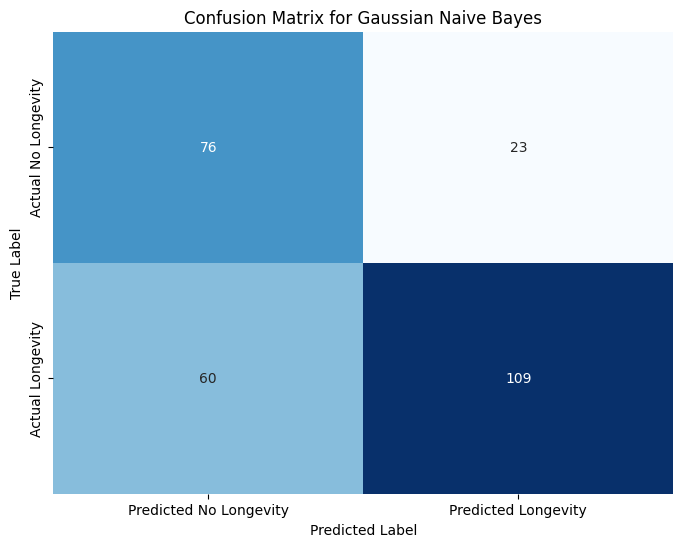

In [72]:
# Make predictions on the scaled test data
y_pred = gnb.predict(X_test)
y_pred_proba = gnb.predict_proba(X_test)[:, 1] # Probabilities for the positive class

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

# Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Longevity', 'Predicted Longevity'],
            yticklabels=['Actual No Longevity', 'Actual Longevity'])
plt.title('Confusion Matrix for Gaussian Naive Bayes')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Identifying Influential Features in Gaussian Naive Bayes

Unlike models such as Linear Regression (which uses coefficients) or tree-based models (which use impurity-based importance), Gaussian Naive Bayes doesn't directly output a 'feature importance' score. Instead, its predictions are driven by the estimated mean and variance of each feature within each class.

For a Gaussian Naive Bayes model, features that are most influential in discriminating between classes (e.g., long vs. short career) are typically those that exhibit:

1.  **Larger differences in means between the classes**: If the average value of a feature is significantly different for players with long careers compared to those with short careers, that feature is highly indicative.
2.  **Smaller variances within each class**: If a feature's values are tightly clustered around its mean within each class, it provides a more consistent signal for that class.

### Interpreting Feature Influence from Model Parameters

To identify potentially influential features, one would typically inspect the `theta_` (means) and `var_` (variances) attributes of the `GaussianNB` model:

*   `gnb.theta_`: Contains the mean of each feature per class.
*   `gnb.var_`: Contains the variance of each feature per class.

By comparing these values, a scouting department could gain insights:

*   **Example**: If `total_points` has a much higher mean for `target_5yrs=1` than for `target_5yrs=0`, it suggests that players who score more points tend to have longer careers. If the variance for `total_points` within each group is small, it implies this trend is consistent.

**Actionable Insight for Scouting**: While not a direct ranking, analyzing these parameters can help scouts understand which statistical profiles are most characteristic of players likely to achieve longevity according to the model. Features with a clear separation in means between the '0' and '1' classes, especially when combined with low variance within those classes, would be considered highly influential.

### Naive Bayes "Independence Assumption" and Its Realism for Basketball Stats

The **Naive Bayes classifier** operates under a fundamental principle called the **"Independence Assumption"** (also known as conditional independence). It assumes that all features are independent of each other, given the class label. In simpler terms, it believes that the presence or absence of one feature does not affect the presence or absence of any other feature, as long as we know the outcome (e.g., whether a player will have a long career or not).

Let's break it down:

*   **Formal Statement**: P(Feature1, Feature2 | Class) = P(Feature1 | Class) * P(Feature2 | Class)

### Realism for Basketball Stats

For basketball statistics, the independence assumption is often **unrealistic** and frequently violated. As you rightly pointed out with the example of "points" and "minutes played", many basketball statistics are highly correlated. Here's why:

1.  **Correlation Between Points and Minutes Played**: A player who plays more minutes (Feature 1) is inherently going to have more opportunities to score points (Feature 2). Therefore, `points` and `minutes played` are **not independent**. If you know a player played a high number of minutes, you can reasonably expect their points total to be higher, regardless of their career longevity.

2.  **Other Examples of Interdependence in Basketball Stats**:
    *   **Field Goals Made (FGM) and Field Goals Attempted (FGA)**: A player cannot make a field goal without attempting one. These are directly linked.
    *   **Rebounds (REB) and Minutes Played (MIN)**: More minutes generally lead to more opportunities for rebounds.
    *   **Assists (AST) and Turnover (TOV)**: These often come from similar ball-handling situations; players with high usage rates might have both high assists and high turnovers.
    *   **Offensive Rebounds (OREB) and Defensive Rebounds (DREB)**: While distinct, a player's overall rebounding prowess often means they excel at both.

### Impact on Naive Bayes Model

Despite this unrealistic assumption, Naive Bayes models can still perform surprisingly well in practice. However, violating the independence assumption can lead to a few issues:

*   **Suboptimal Probability Estimates**: While the classification might still be accurate (predicting the correct class), the probability scores that the model outputs might be overconfident or skewed because it's multiplying independent probabilities when they should be conditionally dependent.
*   **Reduced Performance**: In cases of strong feature dependencies, other models that explicitly account for feature relationships (like Logistic Regression, SVMs, or tree-based models) might outperform Naive Bayes.

In our current dataset, we've already seen evidence of this with features like `fgm`, `fga`, `pts`, `fta`, `3pa`, and `reb` being highly correlated. While we dropped some of these due to multicollinearity, the underlying statistical reality in basketball data remains that many metrics are interconnected. Therefore, when using Gaussian Naive Bayes, we should be mindful that its strong independence assumption is likely not met, which could affect the interpretation of its probability outputs and potentially its predictive power compared to models that handle feature dependencies better.

# Conclusion
## Model Reliability and Limitations: Insights for a Scouting Department

For a scouting department, understanding a predictive model's strengths and weaknesses is crucial for making informed decisions. Here's a summary of our Gaussian Naive Bayes model's performance and key considerations:

### Model Reliability (What the model does well):

*   **Good at Identifying Long-Term Potential (Precision for Class 1)**: The model shows a relatively high precision (0.8258) for predicting that a player *will* play 5+ years in the NBA. This means that when the model says a player will have a long career, it's correct about 83% of the time. This can be valuable for identifying prospects with strong indicators for longevity.
*   **Decent Overall Accuracy**: With an accuracy of 0.6903, the model correctly classifies about 69% of players regarding their career longevity. This suggests it has some predictive power.
*   **Effective at Identifying Players *Without* Long Careers (Recall for Class 0)**: The model has good recall (0.77) for identifying players who *will not* play 5+ years. This means it's good at catching those who are likely to have shorter careers.

### Model Limitations (Where the model struggles and what to consider):

*   **Misses Some Long-Term Players (Lower Recall for Class 1)**: The model's recall for players who *do* achieve 5+ years is 0.6450. This means that while it's accurate when it predicts longevity, it *misses* about 35.5% of players who actually go on to have long careers. A scout might overlook some good prospects if relying solely on this model.
*   **Independence Assumption May Be Unrealistic**: Gaussian Naive Bayes assumes that all player statistics are independent of each other (given career longevity). In reality, many basketball stats (like points, minutes played, field goals made, etc.) are highly correlated. This unrealistic assumption might lead the model to be overconfident in its probability predictions, even if its final classification is often correct. This means the 'why' behind a prediction might not be as robust as with other models.
*   **Potential for Imbalance Impact**: The target variable (`target_5yrs`) is imbalanced, with more players having long careers (831) than short ones (509). While the model still performs reasonably, highly imbalanced datasets can sometimes bias models towards the majority class. This could contribute to the lower recall for the minority class (players with short careers).
*   **Feature Complexity**: The current features are raw and engineered stats. While useful, the model might benefit from more sophisticated features or interactions that capture complex dynamics of player performance over time.

### Actionable Takeaways for Scouting:

*   **Use as a Screening Tool**: The model can serve as an effective first-pass screening tool to highlight players with strong longevity signals (high precision for Class 1) and to flag those with clear indicators of shorter careers (high recall for Class 0).
*   **Combine with Expert Judgment**: Due to the limitations, especially the potential to miss genuinely good prospects (lower recall for Class 1) and the simplifying assumptions, the model's output should always be combined with human scouting expertise, contextual information, and other qualitative assessments.
*   **Focus on High-Confidence Predictions**: For critical decisions, scouts might focus on predictions where the model expresses very high confidence (i.e., very high probability scores for either class).
*   **Consider Other Models**: For future iterations, exploring models that handle feature dependencies more explicitly (like Logistic Regression, SVMs, or tree-based models) could offer different perspectives and potentially improve performance metrics like recall for the positive class.